# In this sheet we will analyze the scrapped data.
 


In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

Get the database

In [2]:
df = pd.read_csv('database.csv')
df["PRICE_SQRM"] = df["PRICE"]/df["SIZE"]
df.head()

,ID,PRICE,SIZE,ROOMS,DATE,OWNER,LAT,LON,PRICE_SQRM
0,67837996,549000,45.62,2,29.04.2026,prywatny,50.656732,17.897874,12034.195528
1,67953693,710000,60.00,3,28.04.2026,prywatny,50.666950,17.937210,11833.333333
2,67954267,639000,64.12,3,28.04.2026,biuro nieruchomości,50.664387,17.933162,9965.689333
3,67926507,460000,46.61,3,28.04.2026,biuro nieruchomości,50.662900,17.897750,9869.126797
4,67686199,779000,75.61,4,28.04.2026,biuro nieruchomości,50.650100,17.854300,10302.869991


How many positions are there for private/agency offers?

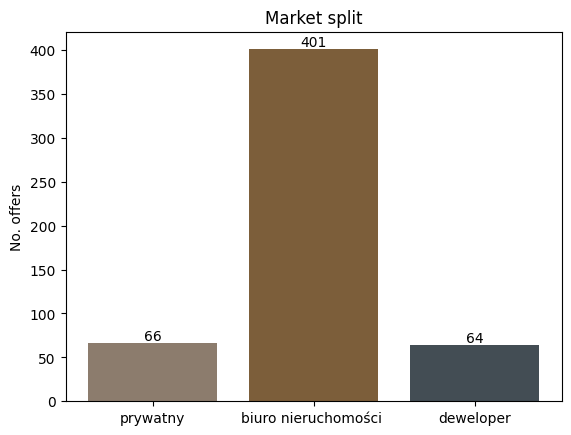

In [29]:
owners = df["OWNER"].unique()

private_offers = df[df["OWNER"] == owners[0]]
agency_offers = df[df["OWNER"] == owners[1]]
developer_offers = df[df["OWNER"] == owners[2]]

private_num = len(private_offers)
agency_num = len(agency_offers)
developer_num = len(developer_offers)


fig, ax = plt.subplots()

values = [private_num,agency_num,developer_num]
bar_labels = owners
bar_colors = ['#8C7C6D', '#7C5E3A', '#434D54']

bar_container = ax.bar(owners, values, label=bar_labels, color=bar_colors)
ax.bar_label(bar_container, fmt="{:,.0f}")
ax.set_ylabel('No. offers')
ax.set_title('Market split')

plt.show()


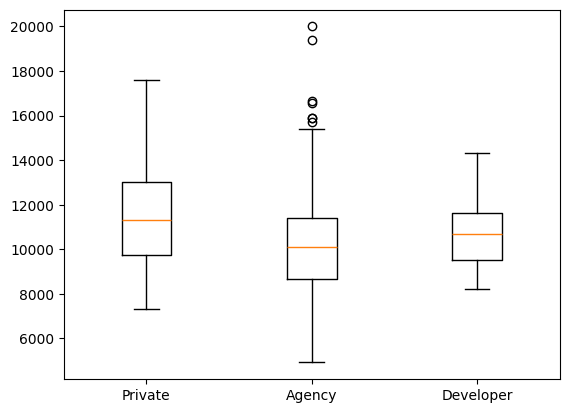

In [26]:
fig, ax = plt.subplots()
ax.boxplot([private_offers["PRICE_SQRM"],agency_offers["PRICE_SQRM"],developer_offers["PRICE_SQRM"]], tick_labels = ["Private","Agency","Developer"])
plt.show()

# Price distribution


What is the price distribution for all offers?

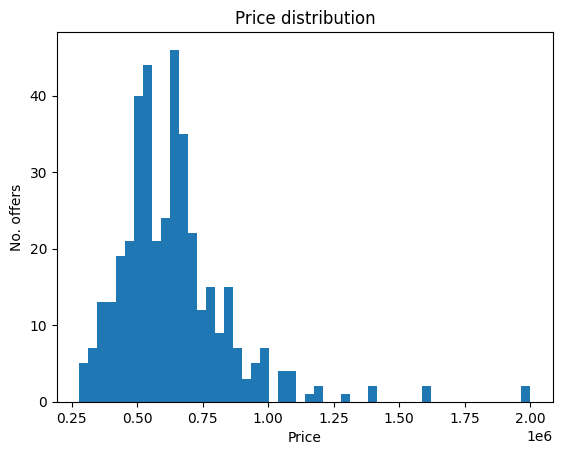

In [32]:
plt.hist(agency_offers["PRICE"],bins = 50)
plt.title("Price distribution")
plt.xlabel("Price")
plt.ylabel("No. offers")
plt.show()

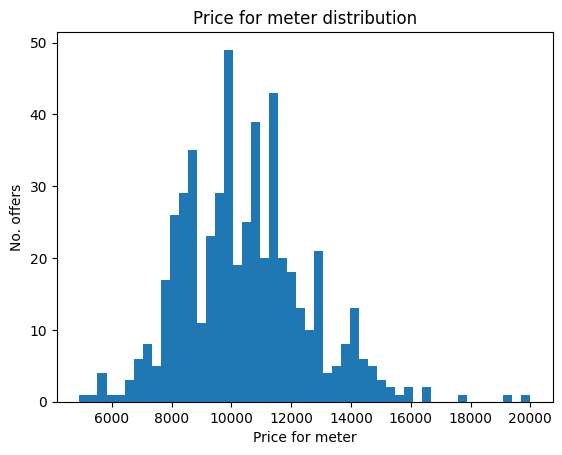

In [27]:
plt.hist(df["PRICE_SQRM"], bins=50)
plt.title("Price for meter distribution")
plt.xlabel("Price for meter")
plt.ylabel("No. offers")
plt.show()

This implies that there are many outliers on the right side, lets filter out the offer that have a price higher than 1M.


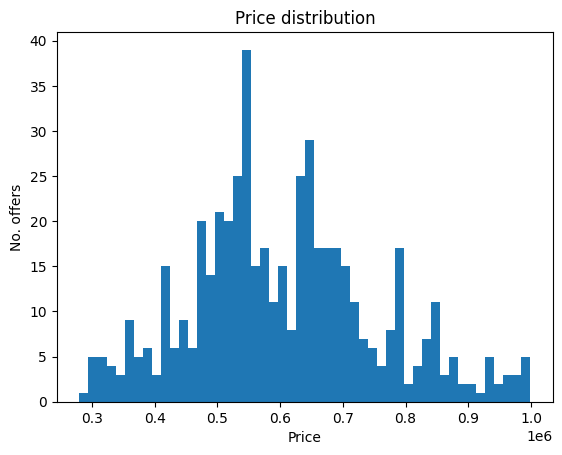

In [16]:
df_resonable = df[df["PRICE"]<=1000000]

plt.hist(df_resonable["PRICE"],bins = 50)
plt.title("Price distribution")
plt.xlabel("Price")
plt.ylabel("No. offers")
plt.show()

## Price distribution with distinction of owner

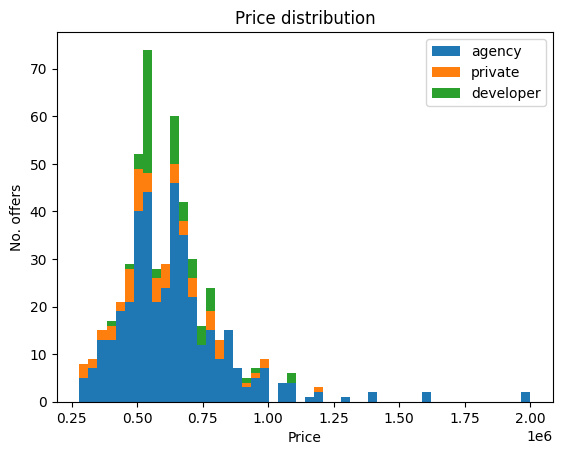

In [18]:
plt.hist([agency_offers["PRICE"],private_offers["PRICE"],developer_offers["PRICE"]],bins = 50, stacked=True, label=["agency","private","developer"])
plt.title("Price distribution")
plt.xlabel("Price")
plt.ylabel("No. offers")
plt.legend()
plt.show()

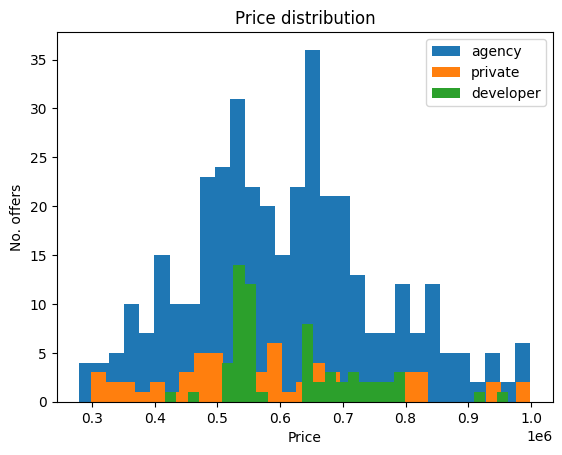

In [19]:
agency_reasonable_offers = agency_offers[agency_offers["PRICE"]<=1000000]
private_reasonable_offers = private_offers[private_offers["PRICE"]<=1000000]
developer_reasonable_offers = developer_offers[developer_offers["PRICE"]<=1000000]

plt.hist(agency_reasonable_offers["PRICE"],bins = 30, label="agency")
plt.hist(private_reasonable_offers["PRICE"],bins = 30, label="private")
plt.hist(developer_reasonable_offers["PRICE"],bins = 30, label="developer")
plt.title("Price distribution")
plt.xlabel("Price")
plt.ylabel("No. offers")
plt.legend()
plt.show()

# Price per square meter

In [ ]:
agency_sqr_price = agency_offers["PRICE"]/agency_offers["SIZE"]
private_sqr_price = private_offers["PRICE"]/private_offers["SIZE"]
developer_sqr_price = developer_offers["PRICE"]/developer_offers["SIZE"]
print(np.mean(agency_sqr_price),np.mean(private_sqr_price),np.mean(developer_sqr_price))

sqr_price = df["PRICE"]/df["SIZE"]
print(np.mean(sqr_price))

10294.785159369247 11314.875049362261 10513.211946236075
10447.217981136613


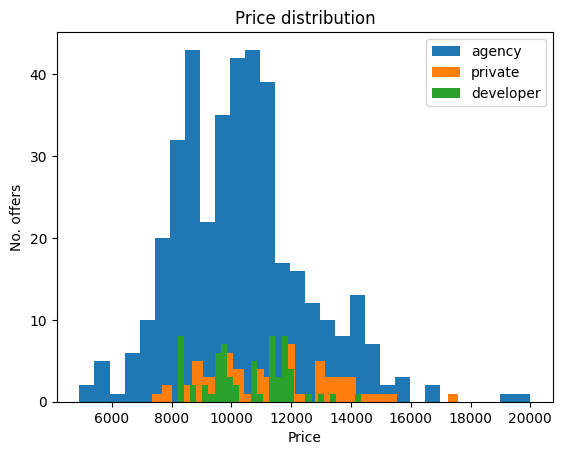

In [ ]:
plt.hist(agency_sqr_price,bins = 30, label="agency")
plt.hist(private_sqr_price,bins = 30, label="private")
plt.hist(developer_sqr_price,bins = 30, label="developer")
plt.title("Price distribution")
plt.xlabel("Price")
plt.ylabel("No. offers")
plt.legend()
plt.show()

# Offers based on number of rooms

Lets analyze the market split based on the number of rooms

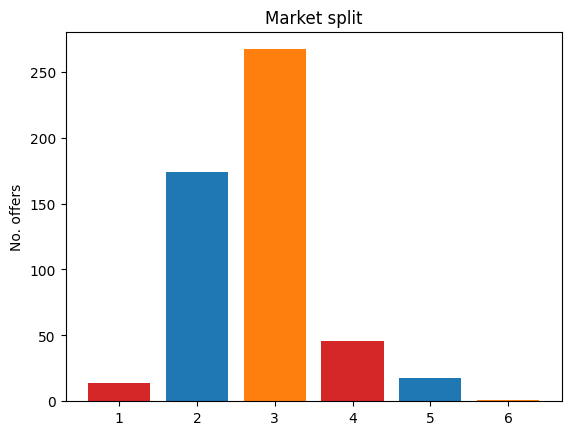

In [ ]:
rooms = df["ROOMS"].unique()
rooms.sort()

fig, ax = plt.subplots()

# i fucking love list comprehension
counts = [len(df[df["ROOMS"] == room]) for room in rooms]
values = rooms
bar_labels = rooms

ax.bar(values, counts, label=bar_labels, color=bar_colors)
ax.set_ylabel('No. offers')
ax.set_title('Market split')

plt.show()

Size analisys based on number of rooms

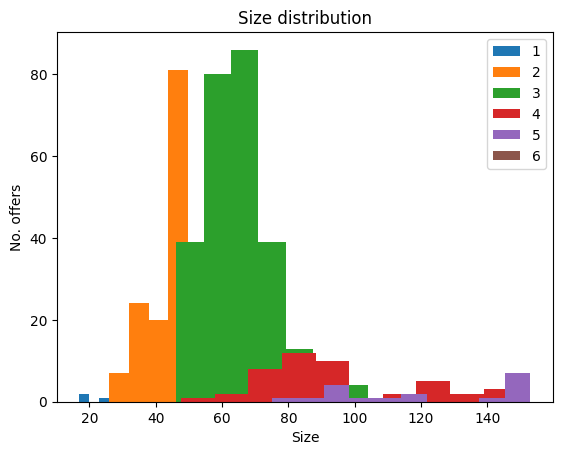

In [ ]:
one_df = df[df["ROOMS"]==1]["SIZE"]
two_df = df[df["ROOMS"]==2]["SIZE"]
three_df = df[df["ROOMS"]==3]["SIZE"]
four_df = df[df["ROOMS"]==4]["SIZE"]
five_df = df[df["ROOMS"]==5]["SIZE"]
six_df = df[df["ROOMS"]==6]["SIZE"]

plt.hist(one_df,bins = 10, label="1")
plt.hist(two_df,bins = 10, label="2")
plt.hist(three_df,bins = 10, label="3")
plt.hist(four_df,bins = 10, label="4")
plt.hist(five_df,bins = 10, label="5")
plt.hist(six_df,bins = 10, label="6")
plt.title("Size distribution")
plt.xlabel("Size")
plt.ylabel("No. offers")
plt.legend()
plt.show()

Price based on number of rooms

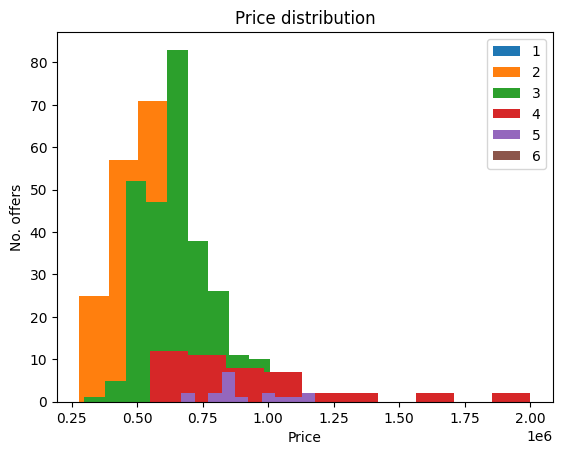

In [23]:
one_df = df[df["ROOMS"]==1]["PRICE"]
two_df = df[df["ROOMS"]==2]["PRICE"]
three_df = df[df["ROOMS"]==3]["PRICE"]
four_df = df[df["ROOMS"]==4]["PRICE"]
five_df = df[df["ROOMS"]==5]["PRICE"]
six_df = df[df["ROOMS"]==6]["PRICE"]

plt.hist(one_df,bins = 10, label="1")
plt.hist(two_df,bins = 10, label="2")
plt.hist(three_df,bins = 10, label="3")
plt.hist(four_df,bins = 10, label="4")
plt.hist(five_df,bins = 10, label="5")
plt.hist(six_df,bins = 10, label="6")
plt.title("Price distribution")
plt.xlabel("Price")
plt.ylabel("No. offers")
plt.legend()
plt.show()

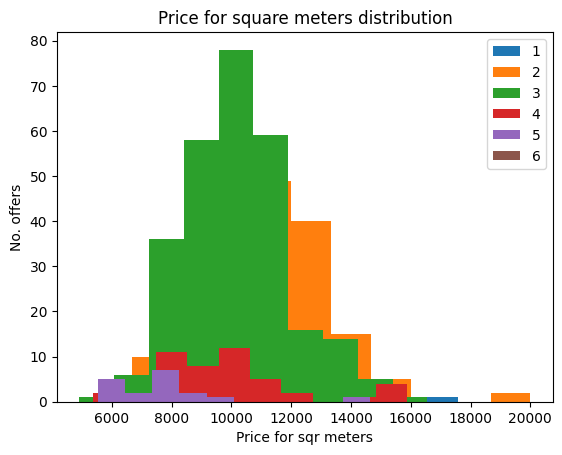

In [22]:
one_df = df[df["ROOMS"]==1]["PRICE"]/df[df["ROOMS"]==1]["SIZE"]
two_df = df[df["ROOMS"]==2]["PRICE"]/df[df["ROOMS"]==2]["SIZE"]
three_df = df[df["ROOMS"]==3]["PRICE"]/df[df["ROOMS"]==3]["SIZE"]
four_df = df[df["ROOMS"]==4]["PRICE"]/df[df["ROOMS"]==4]["SIZE"]
five_df = df[df["ROOMS"]==5]["PRICE"]/df[df["ROOMS"]==5]["SIZE"]
six_df = df[df["ROOMS"]==6]["PRICE"]/df[df["ROOMS"]==6]["SIZE"]

plt.hist(one_df,bins = 10, label="1")
plt.hist(two_df,bins = 10, label="2")
plt.hist(three_df,bins = 10, label="3")
plt.hist(four_df,bins = 10, label="4")
plt.hist(five_df,bins = 10, label="5")
plt.hist(six_df,bins = 10, label="6")
plt.title("Price for square meters distribution")
plt.xlabel("Price for sqr meters")
plt.ylabel("No. offers")
plt.legend()
plt.show()

# Map

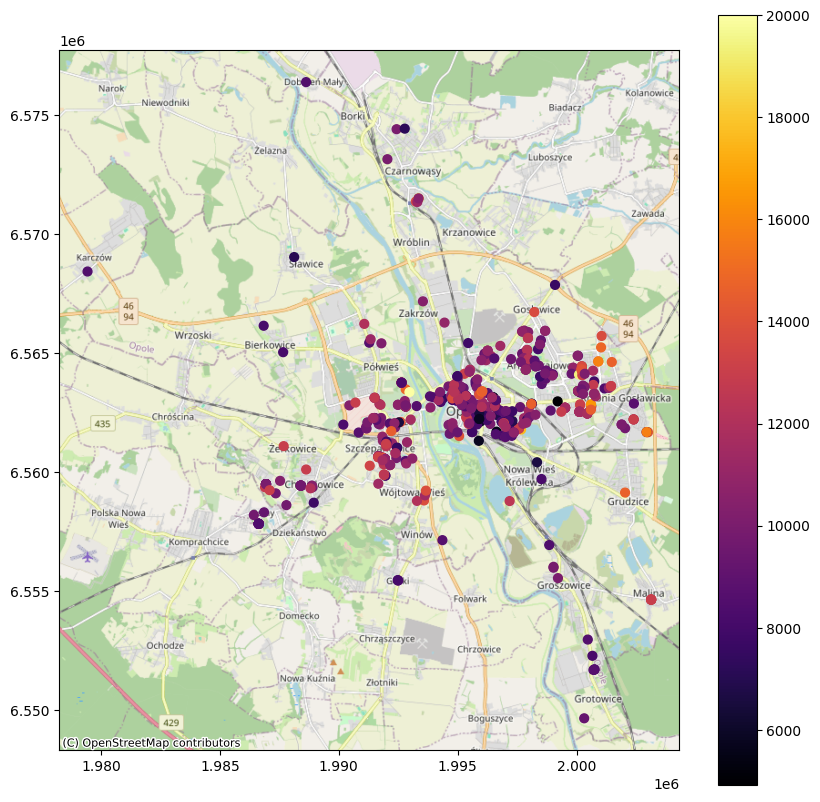

In [33]:
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

# Create geometry column
geometry = [
    Point(xy) for xy in zip(df["LON"], df["LAT"])
]

# Create GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=geometry,
    crs="EPSG:4326"   # GPS coordinates
)

# Convert to web mercator for web tiles
gdf_web = gdf.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))

gdf_web.plot(
    ax=ax,
    column="PRICE_SQRM",
    cmap="inferno", #other colormaps: viridis, plasma, inferno, magma, cividis
    markersize=40,
    legend="True"
)

# Add basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik
)

plt.show()